In [2]:
import scipy as sp
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum, angle
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa
tau = 6.4*1e-13 # scattering time in seconds
from utils import hbar, c, alpha
euler_gamma = 0.57721 # Euler-Mascheroni constant

### This notebook re-creates some of the figures in the paper "Extraordinary optical reflection from sub-wavelength cylinder arrays" by Gomez-Medina

We note that the normalized reciprocal lattice vectors are given by $K_mD=2\pi m$ and the in-plane scattered wavevectors are therefore given as $q_mD=\sqrt{(2\pi)^2(\omega D/(2\pi c))^2-(Q_0D-2\pi m)^2}$, where $Q_0$ is the in-plane wavevector of the incident field, and $\omega/c$ is the modulus free space wavevector

In [3]:
def G_b_sum_term(x, m, Q_0_D = 0.8*pi): # x is omega*D/(2pi*c). G_b_sum_term gives one term in the sum given by Equation 7 of the paper
    K_m = 2*pi*m
    q_m_sqrd = (2*pi)**2*x**2-(Q_0_D-K_m)**2 + 0j
    q_minus_m_sqrd = (2*pi)**2*x**2-(Q_0_D+K_m)**2 + 0j
    return (1/2)*(1j/sqrt(q_m_sqrd) + 1j/sqrt(q_minus_m_sqrd) - 2/K_m) # Sum from equation 7

# G_0_sum_term gives one term in the sum given by Equation 5 of the paper (for x=y=0)
def G_0_sum_term(x, m): # x is omega*D/(2*pi*c) as in G_b_sum_term
    K_m = 2*pi*m
    q_m_sqrd = (2*pi)**2*x**2-(Q_0_D-K_m)**2 + 0j
    return 1j/(2*sqrt(q_m_sqrd))

In [4]:
N = 100000 # Number of frequency/wavelength points sampled
M = 100 # Number of reciprocal lattice sum terms for G_b
x_v = linspace(0.0001, 2, N) # omega*D/(2*pi*c)
G_b_v = zeros(N, dtype=complex) 
Q_0_D = 0.8*pi
for (x_idx, x) in enumerate(x_v):
    G_b = 0
    G_b_zero_term = 1j/(2*sqrt((2*pi)**2*x**2-(Q_0_D)**2 + 0j))
    for m in range(1, M):
        G_b += G_b_sum_term(x, m)
    G_b += euler_gamma/(2*pi) # Last term in Equation 7
    G_b += log(x/2)/(2*pi) # Second to last term in Equation 7
    G_b += G_b_zero_term # First term in Equation 7
    G_b += -1j/4 # Second term in Equation 7
    G_b_v[x_idx] = G_b

In [5]:
epsilon_minus_one_term = 4/9*x_v**2 # Given by the paper
alpha_zz_inv = (1-1j*(pi/4)*epsilon_minus_one_term)/(pi*epsilon_minus_one_term) # Inverse longitudinal polarizability normalized by light wavevector 

### The plot below is Figure 2(a) of the paper

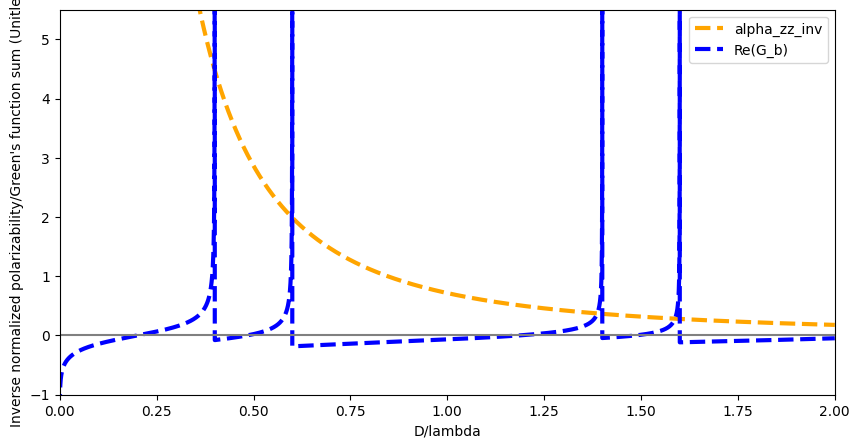

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_v, alpha_zz_inv.real, linestyle="dashed", color="orange", linewidth=3, label="alpha_zz_inv")
ax.plot(x_v, G_b_v.real, linestyle="dashed", color="blue", linewidth=3, label="Re(G_b)")
ax.hlines([0], 0, 2, color="Grey")
ax.set_ylim(-1, 5.5)
ax.set_xlim(0, 2)
ax.set_xlabel("D/lambda");
ax.legend();
ax.set_ylabel("Inverse normalized polarizability/Green's function sum (Unitless)");

### Now we find the reflectance, R, (for s-polarization $\mathbf{E}=E\mathbf{e}_z$) through Equation 14

In [11]:
#N = 100000  Keep number of frequency points same as for the lattice green's function sum and polarizability calculation
M = 20 # Number of reciprocal lattice sum terms
#x_v = linspace(0.0001, 2, N) # omega*D/(2*pi*c) Keep range of wavelengths the same as well, obviously
G_0_v = zeros(N, dtype=complex)
for (x_idx, x) in enumerate(x_v):
    G_0 = 0
    for m in range(-M, M):
        G_0 += G_0_sum_term(x, m)
    G_0_v[x_idx] = G_0

In [13]:
G_0_v_imag = G_0_v.imag
R_term_2 = ((alpha_zz_inv - G_b_v).real)**2 + (G_0_v_imag)**2
R_term_1 = G_0_v_imag/(2*sqrt((2*pi)**2*x_v**2-(Q_0_D)**2 + 0j))
R_v = R_term_1/R_term_2

### The figure below is Figure 2(b) of the paper. Note that below a certain value of $D/\lambda$, the quantity $q_0$ will be imaginary. Below this threshold, the reflectance has no physical meaning since the incident wave would be evanescent away from the array.

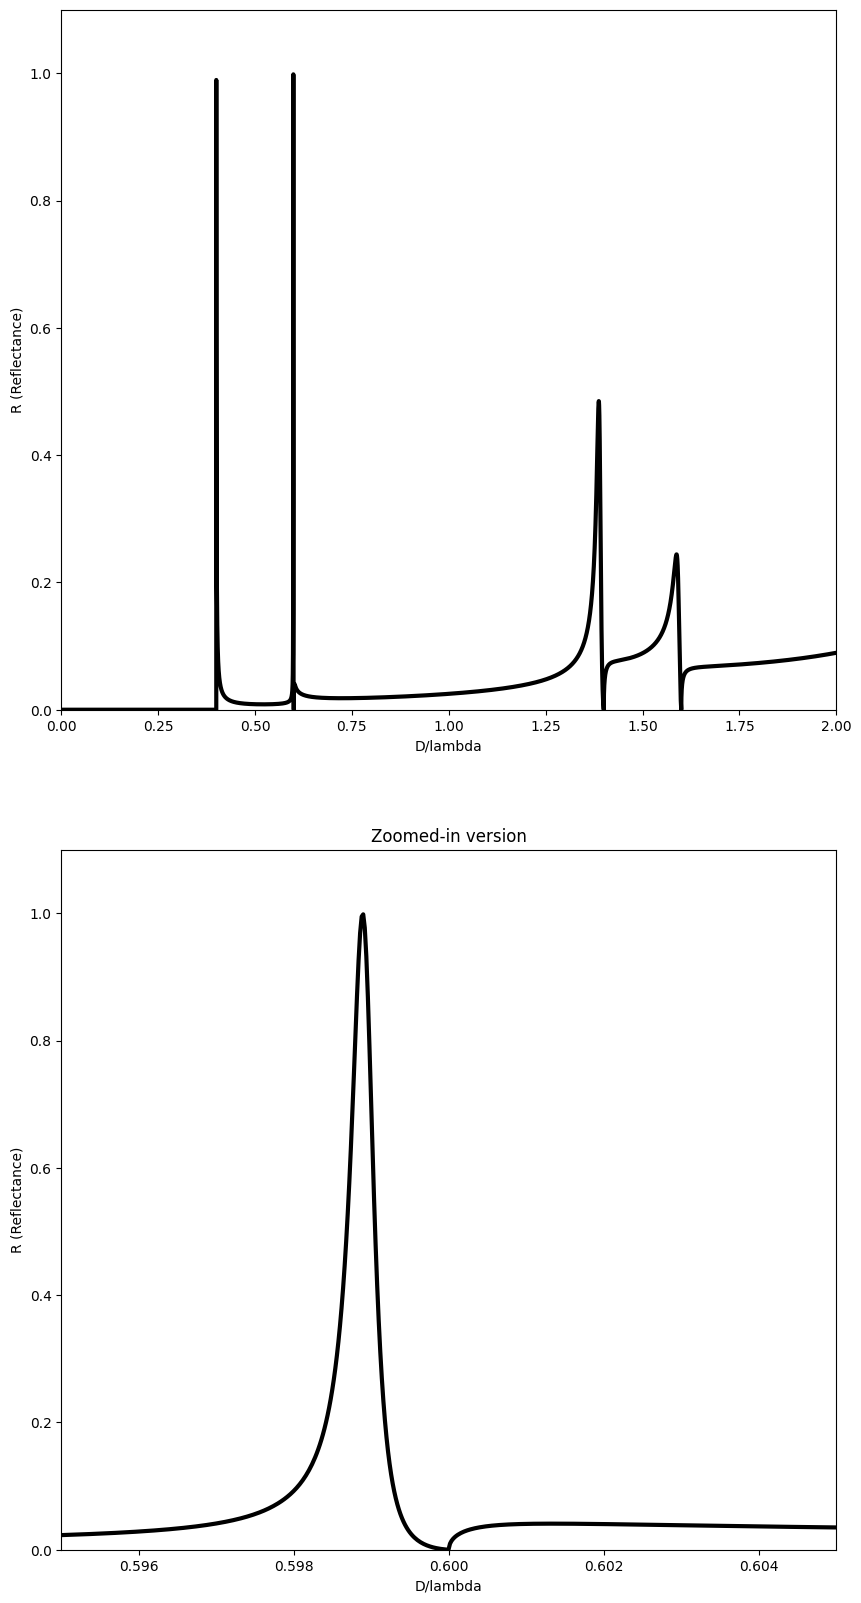

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 20))
ax1.plot(x_v, R_v.real, linewidth=3, color="black")
ax1.set_ylim(0, 1.1);
ax1.set_xlim(0, 2);
ax1.set_ylabel("R (Reflectance)")
ax1.set_xlabel("D/lambda");

ax2.plot(x_v, R_v.real, linewidth=3, color="black")
ax2.set_ylim(0, 1.1);
ax2.set_xlim(0.595, 0.605);
ax2.set_ylabel("R (Reflectance)")
ax2.set_xlabel("D/lambda");
ax2.set_title("Zoomed-in version");

### P-polarized light (Figure 3)
In this case, we have to deal with the in-plane bare polarizabilities, given by Equation 17, which we reiterate below:
$k^2\alpha_{xx}=k^2\alpha_{yy}\approx (2\pi (ka)^2)\frac{\varepsilon-1}{\varepsilon+1}\Big[1-i\frac{\pi}{4}(ka)^2\frac{\varepsilon-1}{\varepsilon+1} \Big]^{-1}$ with $(\varepsilon-1)/(\varepsilon+1)=\frac{8}{9}\frac{D^2}{(2\pi a)^2}$ in the paper. 

Thus we obtain $k^2\alpha_{xx}=k^2\alpha_{yy}\approx \frac{8}{9}\Big[2\pi \frac{(kD)^2}{(2\pi)^2}\Big]\Big[1-i\frac{\pi}{4}\frac{8}{9}\frac{(kD)^2}{(2\pi)^2} \Big]^{-1} = \frac{8}{9}\Big[2\pi x^2 \Big]\Big[1-\frac{i2\pi}{8}\frac{8}{9} x^2 \Big]^{-1}$ (with x defined as in the functions G_b_sum_term

In [18]:
# bare polarizabilities
x_term = (2*pi)*(8/9)*(x_v**2)
alpha_xx_inv  = alpha_yy_inv = (1 - 1j*x_term/8)/x_term

(0.0, 10.0)

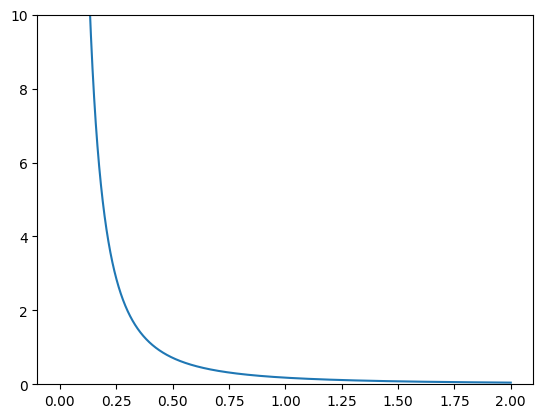

In [22]:
plt.plot(x_v, alpha_xx_inv)
plt.ylim(0, 10)